# MRI Classifier

## Download the Kaggle dataset

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi
import os

os.environ["KAGGLE_CONFIG_DIR"] = r"Your Path to Kaggle Config Directory"     

api = KaggleApi(); api.authenticate()                       
api.dataset_download_files(                                   
    "uraninjo/augmented-alzheimer-mri-dataset-v2",            
    path=r"Your Path to Download Directory",
    unzip=True, force=True)


# Dependencias y librerías

In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import warnings

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image, image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow import keras
import tensorflow as tf
from IPython.display import Image, display
import matplotlib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils import class_weight



from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# Data preprocessing

In [2]:
SEED = 54
tf.random.set_seed(SEED)
np.random.seed(SEED)
warnings.simplefilter('ignore')

In [3]:
IMG_SIZE = (176, 208)
BATCH_SIZE = 32
AUTOTUNE = tf.data.experimental.AUTOTUNE

TRAIN_DIR = "Alzheimer_s Dataset/train"
TEST_DIR = "Alzheimer_s Dataset/test"

In [ ]:
# # run this cell once only
# import os
# import shutil
# from sklearn.model_selection import train_test_split

# SOURCE_DIR = "Alzheimer_s Dataset/All"
# TARGET_BASE = "Alzheimer_s Dataset"

# class_names = os.listdir(SOURCE_DIR)

# all_filepaths = []
# all_labels = []
# for class_name in class_names:
#     class_dir = os.path.join(SOURCE_DIR, class_name)
#     for fname in os.listdir(class_dir):
#         if fname.lower().endswith((".jpg", ".jpeg", ".png")):
#             all_filepaths.append(os.path.join(class_dir, fname))
#             all_labels.append(class_name)

# X_temp, X_test, y_temp, y_test = train_test_split(
#     all_filepaths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=SEED
# )


# def copy_files(file_list, label_list, split_name):
#     for src, label in zip(file_list, label_list):
#         dest_dir = os.path.join(TARGET_BASE, split_name, label)
#         os.makedirs(dest_dir, exist_ok=True)
#         dest_path = os.path.join(dest_dir, os.path.basename(src))
#         shutil.copy2(src, dest_path)

# copy_files(X_train, y_train, "train")
# copy_files(X_val, y_val, "val")
# copy_files(X_test, y_test, "test")



In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

Found 23108 files belonging to 4 classes.
Using 18487 files for training.
Found 23108 files belonging to 4 classes.
Using 4621 files for validation.
Found 11498 files belonging to 4 classes.


In [5]:
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
train_ds.class_names = class_names
val_ds.class_names = class_names
test_ds.class_names = class_names

NUM_CLASSES = len(class_names)

Train :  MildDemented  count  4905
Train :  ModerateDemented  count  3511
Train :  NonDemented  count  5179
Train :  VeryMildDemented  count  4892
Validation :  MildDemented  count  1188
Validation :  ModerateDemented  count  884
Validation :  NonDemented  count  1349
Validation :  VeryMildDemented  count  1200
Test :  MildDemented  count  2240
Test :  ModerateDemented  count  1034
Test :  NonDemented  count  4640
Test :  VeryMildDemented  count  3584


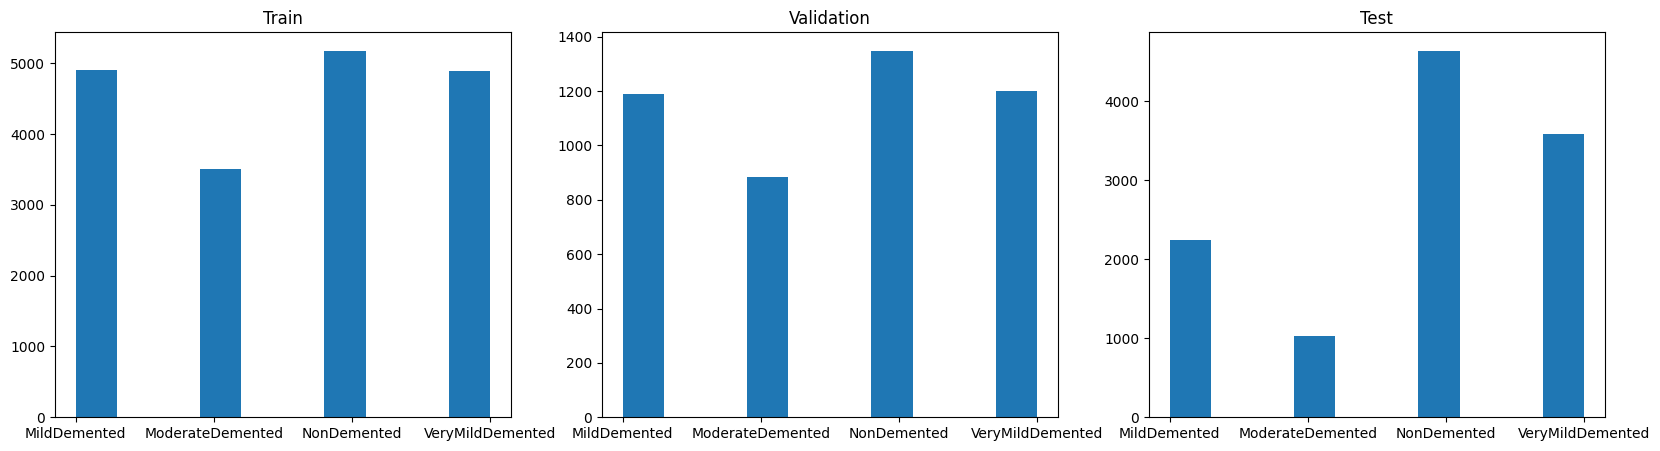

In [6]:
ds = [train_ds, val_ds, test_ds]
ds_string = ['Train', 'Validation', 'Test']
plt.figure(figsize=(20, 5))

for i in range(3):
  ax = plt.subplot(1, 3, i + 1)
  current_ds = ds[i]
  true_categories = tf.concat([y for x, y in current_ds], axis=0).numpy().astype(int)
  true_categories = [class_names[i] for i in sorted(true_categories)]

  for tipe in class_names:
    print(ds_string[i],': ',tipe,' count ',true_categories.count(tipe))
  plt.hist(true_categories)
  plt.title(ds_string[i])

In [ ]:
fig = plt.figure(figsize =(10, 7))
plt.pie([len(train_ds), len(val_ds), len(test_ds)], labels = ["Train", "Val", "Test"],  autopct='%1.1f%%')
plt.title("Training, validation and test sets percentages")
# show plot
plt.show()

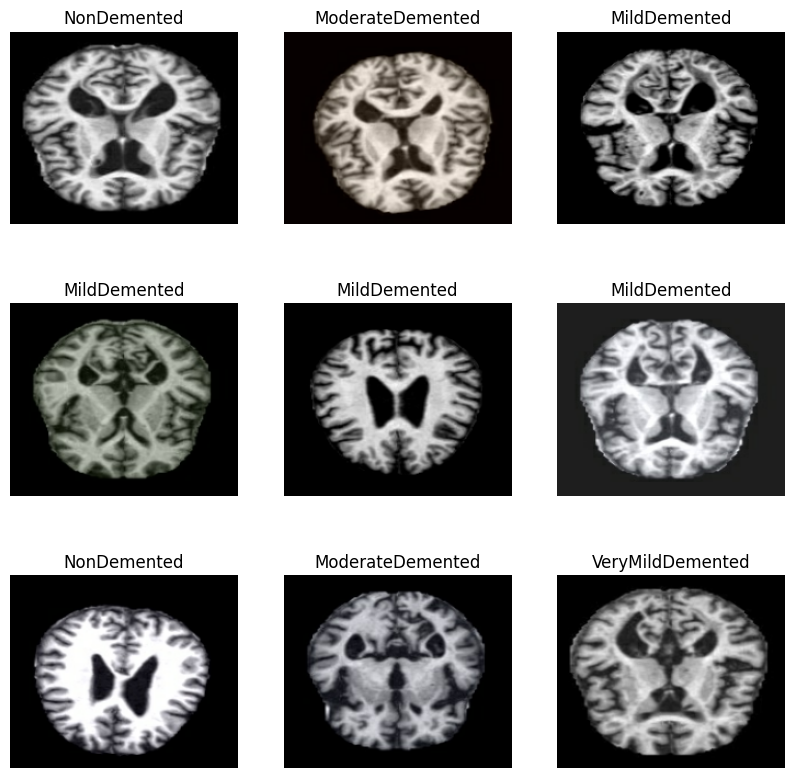

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_ds.class_names[labels[i]])
    plt.axis("off")

In [9]:
def one_hot_label(image, label):
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


train_ds_prefetch = train_ds.map(one_hot_label, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)
val_ds_prefetch = train_ds.map(one_hot_label, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)
test_ds_prefetch = test_ds.map(one_hot_label, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)

## Models

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50

def build_resnet50_finetune(img_size=(224, 224), n_classes=4,
                            dropout_rate=0.3):

    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size[0], img_size[1], 3)
    )
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inputs=base_model.input, outputs=outputs, name="ResNet50_FT")
    return model, base_model


In [ ]:
from sklearn.utils import class_weight
import numpy as np

EPOCHS_A = 5      
EPOCHS_B = 10     
PATIENCE = 5

model, base_model = build_resnet50_finetune(img_size=IMG_SIZE, n_classes=len(class_names))

y_train = np.concatenate([y for _, y in train_ds_prefetch]).argmax(1)
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(weights)}
print("Class-weight:", class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history_a = model.fit(
    train_ds_prefetch,
    epochs=EPOCHS_A,
    validation_data=val_ds_prefetch,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

for layer in base_model.layers:
    if layer.name.startswith("conv5_block"):
        layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),   
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history_b = model.fit(
    train_ds_prefetch,
    epochs=EPOCHS_B,
    validation_data=val_ds_prefetch,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

model.save("resnet_finetuned.h5")
model.summary(line_length=120)


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

model = load_model("resnet_finetuned.h5", compile=False)

_, H, W, C = model.input_shape
print("Model expects:", (H, W, C))

img_path = r"Your Path to Test Image"  # Replace with your image path
orig = load_img(img_path, target_size=(H, W))
orig_arr = img_to_array(orig).astype("float32")

x = preprocess_input(orig_arr[None, ...])
y_pred = model.predict(x)
print("Output probs:", y_pred)
print("Predicted class:", np.argmax(y_pred, axis=1))


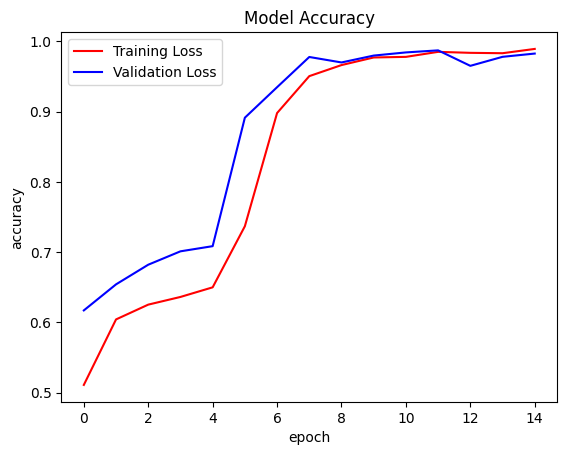

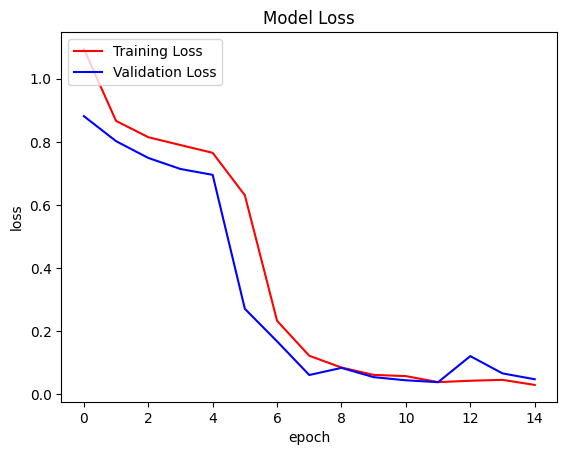

In [ ]:
import matplotlib.pyplot as plt

metrics = ['accuracy', 'loss']       
combined = {}

for m in metrics:
    combined[m] = history_a.history[m] + history_b.history[m]
    combined['val_'+m] = history_a.history['val_'+m] + history_b.history['val_'+m]

def plot_metric(metric_name, title=None):
    plt.figure()
    plt.plot(combined[metric_name], color='red')
    plt.plot(combined['val_'+metric_name], color='blue')
    plt.title(title or f"Model {metric_name}")
    plt.ylabel(metric_name)
    plt.xlabel("epoch")
    plt.legend(["Training Loss", "Validation Loss"], loc="upper left")
    plt.show()

plot_metric("accuracy", "Model Accuracy")
plot_metric("loss",     "Model Loss")


In [20]:
test_scores = model.evaluate(test_ds_prefetch)
test_acc = model.evaluate(test_ds_prefetch, verbose=1)

360/360 [==============================] - 131s 363ms/step - loss: 0.2087 - accuracy: 0.9362 - auc: 0.9911


In [21]:
y_pred = model.predict(test_ds_prefetch, verbose=1)

360/360 [==============================] - 130s 362ms/step


In [22]:
predicted_categories = tf.argmax(y_pred, axis=1).numpy()
predicted_categories

array([3, 0, 2, ..., 2, 3, 0], dtype=int64)

In [23]:
true_categories = tf.concat([y for x, y in test_ds_prefetch], axis=0)
true_categories = tf.argmax(true_categories, axis=1).numpy()
#true_categories_label = true_categories.numpy()
true_categories_label = [class_names[int(y)] for y in true_categories]
print(true_categories)


[3 0 2 ... 2 3 0]


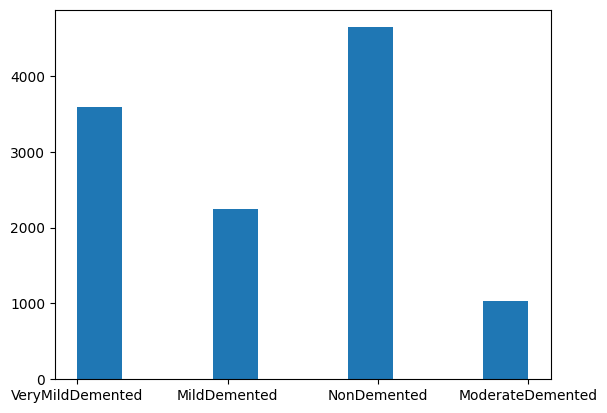

In [18]:
plt.hist(true_categories_label)
plt.show()

In [ ]:
cm = confusion_matrix(true_categories, predicted_categories)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.show()
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format=".00%")
plt.show()


In [ ]:
print(classification_report( true_categories, predicted_categories, target_names=class_names))

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = r'Yout Path to Test Directory'  # Replace with your test directory path

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 11498 images belonging to 4 classes.


1/1 [==============================] - 0s 80ms/step


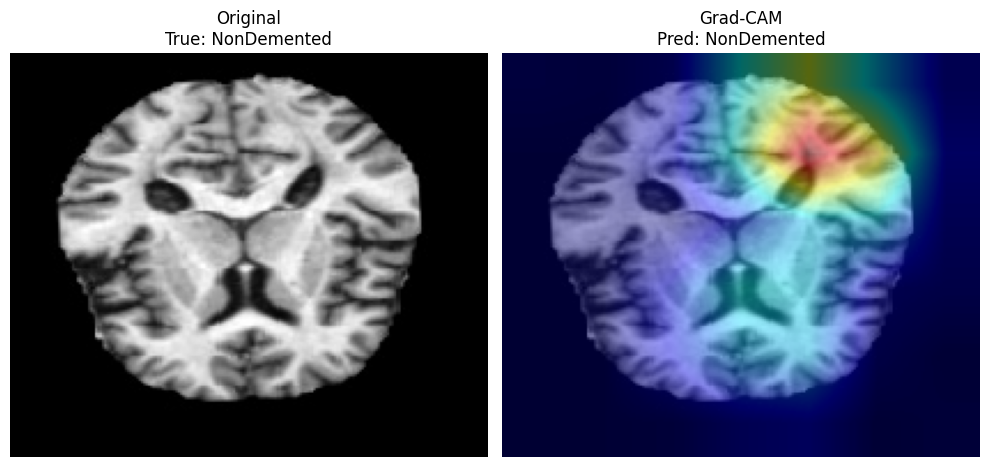

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

TARGET_SIZE = (176, 208)

idx = np.random.randint(len(test_generator.filepaths))
img_path = test_generator.filepaths[idx]
true_idx = test_generator.classes[idx]

orig = load_img(img_path, target_size=TARGET_SIZE)
orig_arr = img_to_array(orig).astype('uint8')

class_indices = test_generator.class_indices
idx2class = {v: k for k, v in class_indices.items()}
true_label = idx2class[true_idx]

x = preprocess_input(np.expand_dims(orig_arr.copy(), axis=0))
preds = model.predict(x)
pred_idx = np.argmax(preds[0])
pred_label = idx2class[pred_idx]

last_conv_layer = model.get_layer("conv5_block3_out")
grad_model = tf.keras.models.Model(
    inputs=[model.inputs],
    outputs=[last_conv_layer.output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, pred_idx]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap) + 1e-8
heatmap = 1.0 - heatmap
heatmap = heatmap.numpy()
heatmap = cv2.resize(heatmap, TARGET_SIZE[::-1])
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig_arr, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(orig_arr.astype('uint8'))
plt.title(f"Original\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f"Grad-CAM\nPred: {pred_label}")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
images, labels = next(iter(train_ds))
img = images[0]
label = labels[0]

input_arr = tf.expand_dims(img, axis=0)
preds = model.predict(input_arr, verbose=0)
pred_idx = tf.argmax(preds[0])

heatmap = make_gradcam_heatmap(input_arr, model, last_conv_layer, pred_idx)
overlay = overlay_gradcam_on_image(img, heatmap, alpha=0.6)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(restore_image_simple(img))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f"Grad-CAM\nTrue: {train_ds.class_names[label]} | Pred: {train_ds.class_names[int(pred_idx)]}")
plt.axis("off")
plt.tight_layout()
plt.show()


In [62]:
print(np.min(img.numpy()), np.max(img.numpy()))


0.0 255.0


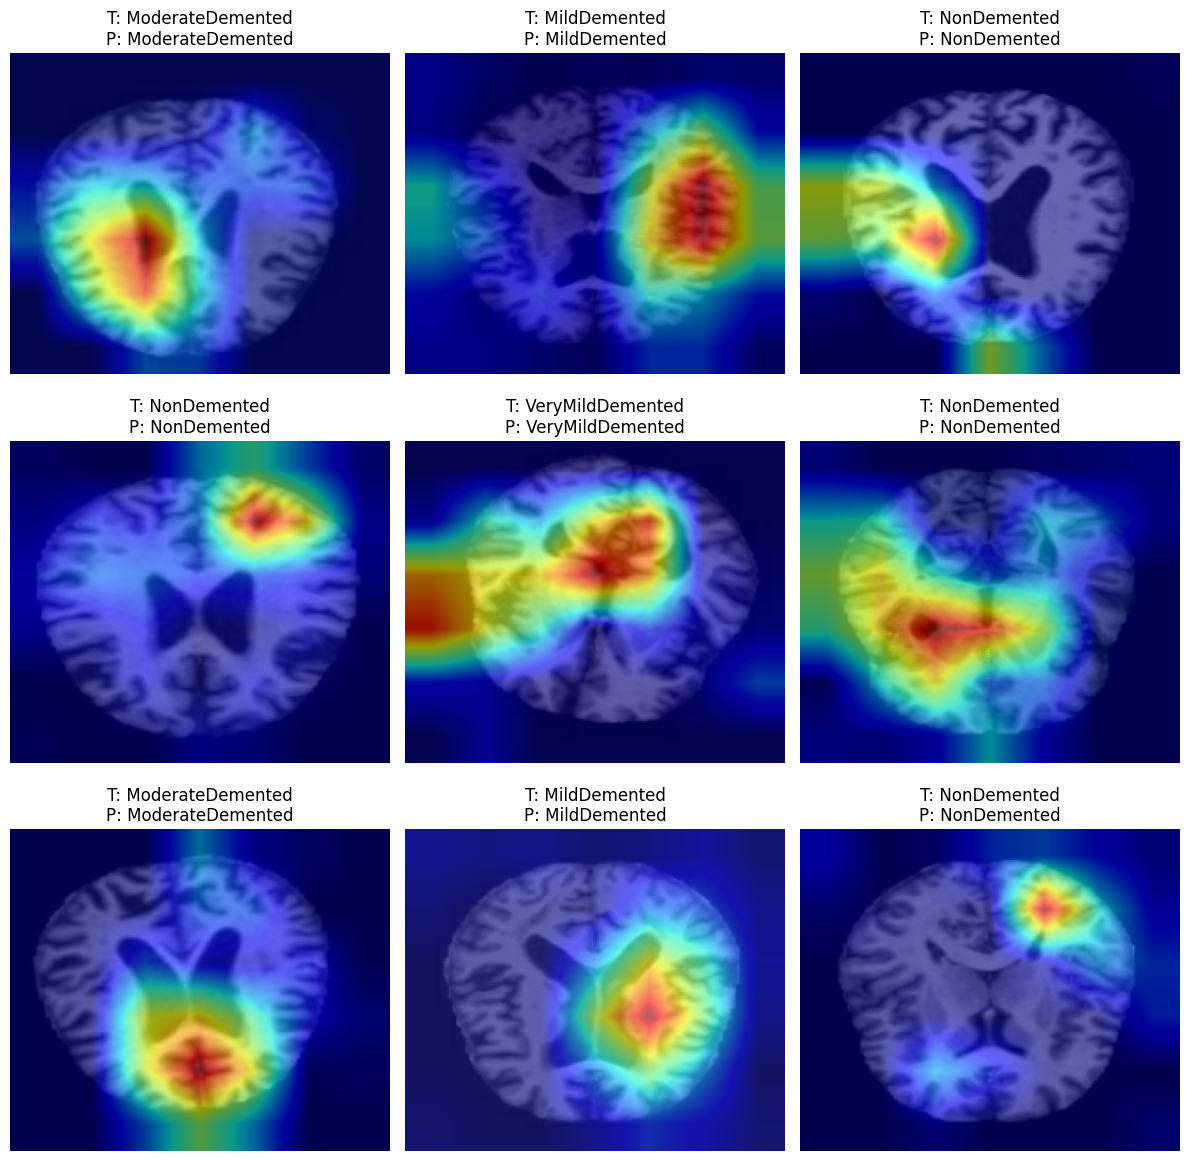

In [63]:
last_conv_layer = "conv5_block3_out"
fig, axes = plt.subplots(3, 3, figsize=(12,12))
images, labels = next(iter(train_ds))

for i in range(9):
    img = images[i]
    label = labels[i]
    inp = tf.expand_dims(img, axis=0)
    preds = model.predict(inp, verbose=0)
    pid = tf.argmax(preds[0])
    # heatmap + overlay
    hm = make_gradcam_heatmap(inp, model, last_conv_layer, pid)
    sup = overlay_gradcam_on_image(img, hm, alpha=0.6)
    ax = axes[i//3, i%3]
    ax.imshow(sup)
    ax.set_title(f"T: {train_ds.class_names[label]}\nP: {train_ds.class_names[int(pid)]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import cv2, itertools
import numpy as np
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.applications.resnet50 import preprocess_input

def apply_small_perturbations(img_uint8):
    angle = np.random.uniform(-5, 5)
    h, w = img_uint8.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    rot = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    noise = np.random.normal(0, 5, img_uint8.shape).astype(np.int16)
    perturbed = np.clip(rot.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return perturbed

def gradcam_gray(img_tensor, model, last_conv_layer, pred_idx):
    x = tf.expand_dims(img_tensor, axis=0)
    x_proc = preprocess_input(x.numpy().copy())
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x_proc)
        loss = preds[:, pred_idx]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heat = tf.reduce_sum(conv_out[0] * pooled, axis=-1)
    heat = tf.maximum(heat, 0) / (tf.reduce_max(heat) + 1e-8)
    heat = 1.0 - heat
    return cv2.resize(heat.numpy().astype(np.float32), (200, 200))

def ssim_score(h1, h2):
    return ssim(h1, h2, data_range=1.0)


In [ ]:
n_samples = 30  
stab_scores = []
last_conv_layer = "conv5_block3_out"

for images, labels in train_ds.unbatch().batch(1).take(n_samples):
    for i in range(images.shape[0]):
        img = images[i]
        label = labels[i]
        pred_idx = tf.argmax(model.predict(tf.expand_dims(img, axis=0), verbose=0)[0])

        orig = (img.numpy() * 255).astype(np.uint8)
        h0 = gradcam_gray(img, model, last_conv_layer, pred_idx)

        pert = apply_small_perturbations(orig)
        pert_tensor = tf.convert_to_tensor(pert / 255.0, dtype=tf.float32)
        h1 = gradcam_gray(pert_tensor, model, last_conv_layer, pred_idx)

        stab_scores.append(ssim_score(h0, h1))

print(f"Grad-CAM Stability (mean SSIM over {len(stab_scores)} samples): {np.mean(stab_scores):.4f}")


In [81]:
from collections import defaultdict

class_names = train_ds.class_names
cons_by_cls = {}
pair_ssim_all = []

n_per_class = 8
last_conv_layer = "conv5_block3_out"

cls_to_heatmaps = defaultdict(list)

for images, labels in train_ds.unbatch().batch(1):
    img = images[0]
    label = labels[0].numpy()
    cls = class_names[label]
    if len(cls_to_heatmaps[cls]) >= n_per_class:
        continue
    pred_idx = tf.argmax(model.predict(tf.expand_dims(img, axis=0), verbose=0)[0])
    heat = gradcam_gray(img, model, last_conv_layer, pred_idx)
    cls_to_heatmaps[cls].append(heat)

for cls, heats in cls_to_heatmaps.items():
    if len(heats) < 2: continue
    scores = [ssim_score(h1, h2) for h1, h2 in itertools.combinations(heats, 2)]
    cons_by_cls[cls] = np.mean(scores)
    pair_ssim_all.extend(scores)

print("Grad-CAM Consistency (mean pairwise SSIM):")
for cls, score in cons_by_cls.items():
    print(f"  {cls:<18}: {score:.4f}")
print(f"Overall mean       : {np.mean(pair_ssim_all):.4f}")



Grad-CAM Consistency (mean pairwise SSIM):
  ModerateDemented  : 0.8362
  MildDemented      : 0.7885
  NonDemented       : 0.7885
  VeryMildDemented  : 0.6416
Overall mean       : 0.7637


## LIME

100%|██████████| 1000/1000 [00:19<00:00, 51.00it/s]


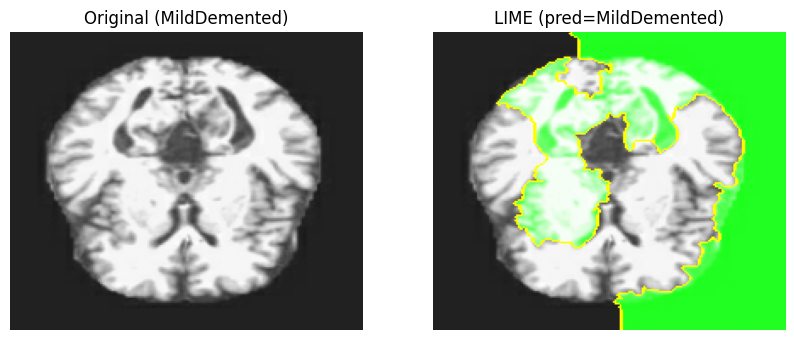

In [34]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

def predict_fn(images_batch):
    x = preprocess_input(images_batch.astype(np.float32))  
    return model.predict(x, verbose=0)


def get_lime_overlay(img_uint8, top_labels=1, num_features=10, hide_rest=False, positive_only=False):
    explanation = explainer.explain_instance(
        image=img_uint8, 
        classifier_fn=predict_fn,
        top_labels=top_labels,
        hide_color=0, 
        num_samples=1000
    )
    label = explanation.top_labels[0]
    
    temp, mask = explanation.get_image_and_mask(
        label,
        positive_only=positive_only,
        num_features=num_features,
        hide_rest=hide_rest
    )
    highlighted = mark_boundaries(temp / 255.0, mask)
    return highlighted, label


images, labels = next(iter(train_ds))
img = images[0].numpy().astype(np.uint8)
orig = img.copy()
lime_img, lime_label = get_lime_overlay(img, num_features=10, positive_only=False, hide_rest=False)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(orig)
plt.title(f"Original ({train_ds.class_names[labels[0]]})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lime_img)
plt.title(f"LIME (pred={train_ds.class_names[lime_label]})")
plt.axis("off")
plt.show()


100%|██████████| 1000/1000 [00:20<00:00, 47.80it/s]


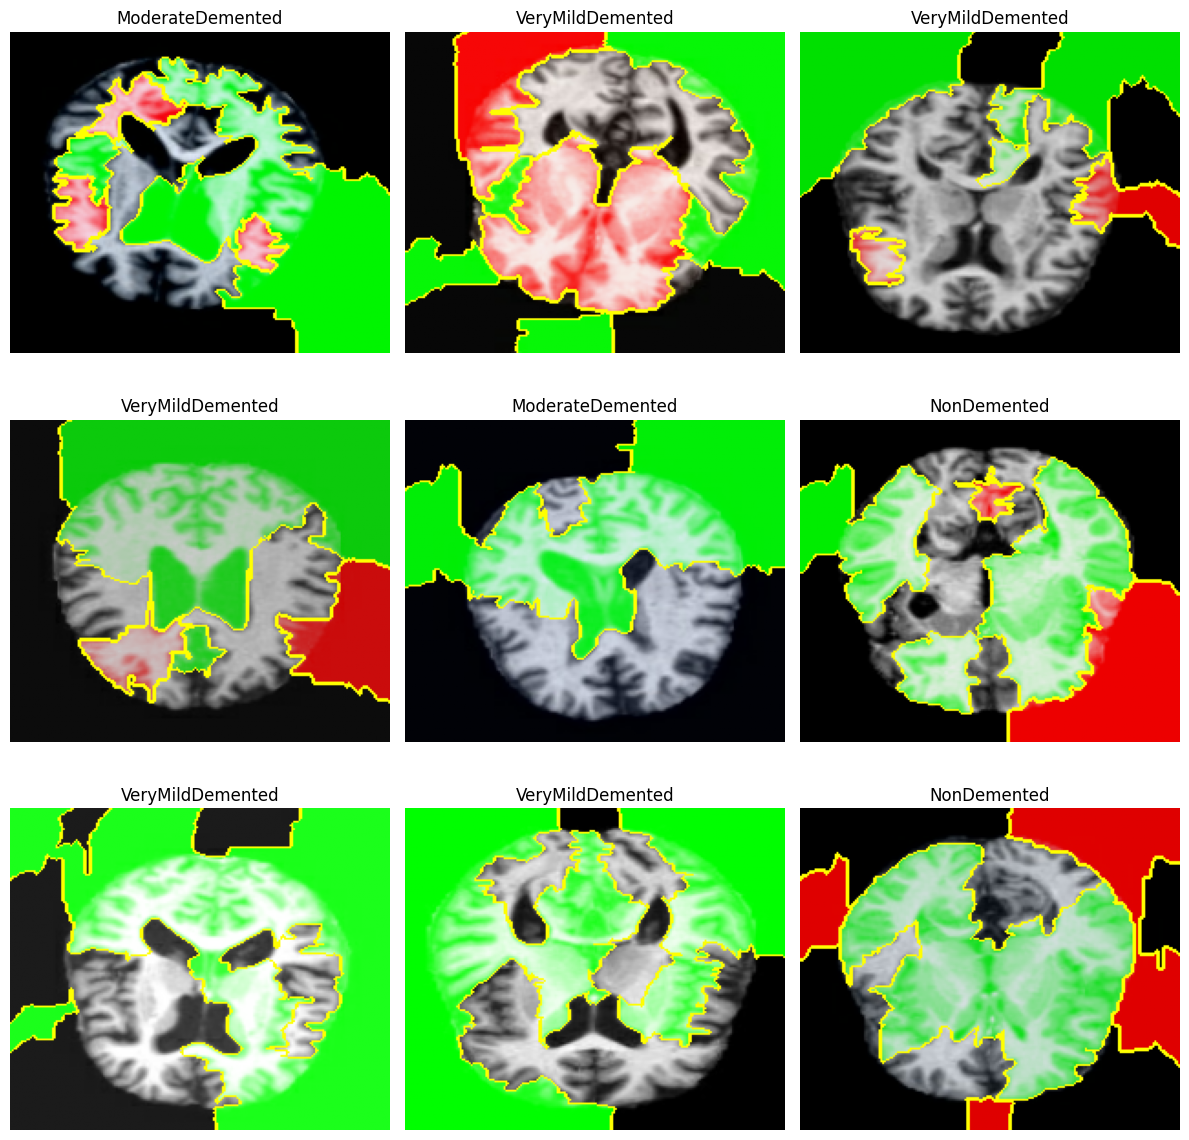

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
images, labels = next(iter(train_ds))

for i in range(9):
    img = images[i].numpy().astype(np.uint8)
    lime_img, _ = get_lime_overlay(img, num_features=10, positive_only=False, hide_rest=False)
    ax = axes[i // 3, i % 3]
    ax.imshow(lime_img)
    ax.set_title(train_ds.class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np, cv2, itertools
import tensorflow as tf
from lime import lime_image
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

explainer = lime_image.LimeImageExplainer()

def predict_fn(images_batch):
    x = preprocess_input(images_batch.astype(np.float32))
    return model.predict(x, verbose=0)

def lime_gray(img_uint8, label=None):
    explanation = explainer.explain_instance(
        image=img_uint8,
        classifier_fn=predict_fn,
        top_labels=1 if label is None else 5,
        labels=None if label is None else [label],
        hide_color=0,
        num_samples=1000
    )
    target_label = label if label is not None else explanation.top_labels[0]
    _, mask = explanation.get_image_and_mask(
        target_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )
    return mask.astype(np.float32)

def apply_small_perturbations(img_uint8):
    angle = np.random.uniform(-5, 5)
    h, w = img_uint8.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
    rot = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    noise = np.random.normal(0, 5, img_uint8.shape).astype(np.int16)
    perturbed = np.clip(rot.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return perturbed

def ssim_score(h1, h2):
    return ssim(h1, h2, data_range=1.0)

# ====== 1) Stability ======
n_samples = 50
stab_scores = []

for _ in range(n_samples):
    idx = np.random.randint(len(test_generator.filepaths))
    arr_orig = img_to_array(load_img(test_generator.filepaths[idx], target_size=(200,200))).astype('uint8')
    x_orig = preprocess_input(np.expand_dims(arr_orig.copy(), axis=0))
    pred_idx = np.argmax(model.predict(x_orig, verbose=0)[0])

    h0 = lime_gray(arr_orig, label=pred_idx)
    pert = apply_small_perturbations(arr_orig)
    h1 = lime_gray(pert, label=pred_idx)

    stab_scores.append(ssim_score(h0, h1))

print(f"\nLIME Stability (mean SSIM over {n_samples} samples): {np.mean(stab_scores):.4f}")

# ====== 2) Consistency ======
idx2class = {v: k for k, v in test_generator.class_indices.items()}
cons_by_cls = {}
pair_ssim_all = []

n_per_class = 10
np.random.seed(42)

for cls_id, cls_name in idx2class.items():
    idxs = np.where(test_generator.classes == cls_id)[0]
    if len(idxs) < 2:
        continue
    sel = np.random.choice(idxs, min(n_per_class, len(idxs)), replace=False)
    heatmaps = []
    for ix in sel:
        arr = img_to_array(load_img(test_generator.filepaths[ix], target_size=(200, 200))).astype('uint8')
        x = preprocess_input(np.expand_dims(arr.copy(), axis=0))
        pred_idx = np.argmax(model.predict(x, verbose=0)[0])
        heatmaps.append(lime_gray(arr, label=pred_idx))

    pair_scores = [ssim_score(h1, h2) for h1, h2 in itertools.combinations(heatmaps, 2)]
    cons_by_cls[cls_name] = np.mean(pair_scores)
    pair_ssim_all.extend(pair_scores)

print("\nLIME Consistency (mean pairwise SSIM):")
for cls_name, score in cons_by_cls.items():
    print(f"  {cls_name:<12}: {score:.4f}")
print(f"Overall mean  : {np.mean(pair_ssim_all):.4f}")


100%|██████████| 1000/1000 [00:23<00:00, 42.63it/s]



LIME Stability (mean SSIM over 50 samples): 0.3813


100%|██████████| 1000/1000 [00:22<00:00, 44.77it/s]


LIME Consistency (mean pairwise SSIM):
  MildDemented: 0.2946
  ModerateDemented: 0.3761
  NonDemented : 0.3749
  VeryMildDemented: 0.2671
Overall mean  : 0.3282


## SHAP

PartitionExplainer explainer: 2it [00:18, 18.29s/it]               


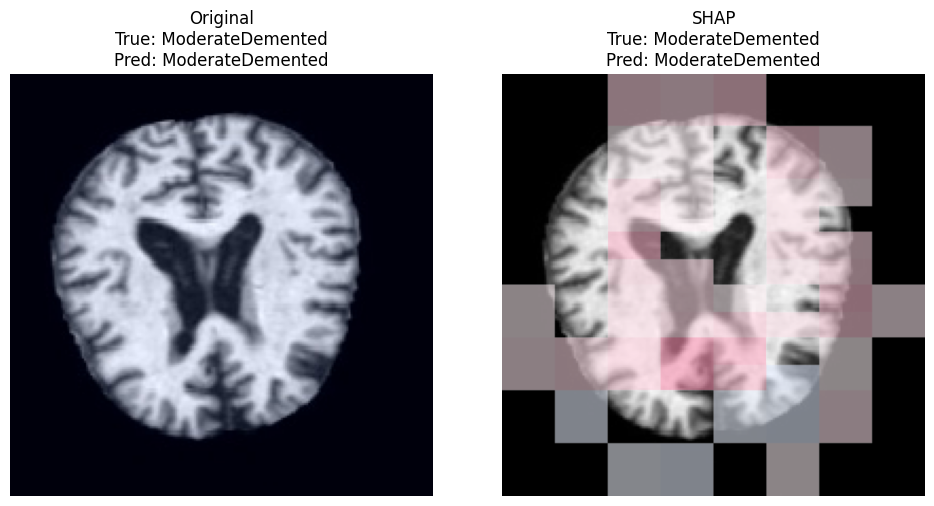

In [ ]:
import numpy as np, shap, cv2, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from skimage.segmentation import slic
from matplotlib.colors import LinearSegmentedColormap

N_SEGMENTS      = 5000
COMPACTNESS     = 8
ALPHA_THRESHOLD = 0.10
ALPHA_LEVEL     = 0.55

test_dir = r'Your Path to Test Directory'  # Replace with your test directory path

import os, random
classes = os.listdir(test_dir)
cls      = random.choice(classes)
imgs     = os.listdir(os.path.join(test_dir, cls))
img_path = os.path.join(test_dir, cls, random.choice(imgs))

orig_arr  = img_to_array(load_img(img_path, target_size=(200,200))).astype(np.uint8)
true_label = cls

def predict_fn(x):
    return model.predict(preprocess_input(x.copy()), verbose=0)

segments = slic(
    orig_arr, 
    n_segments=N_SEGMENTS, 
    compactness=COMPACTNESS,
    sigma=1, 
    start_label=0,
    enforce_connectivity=True
)

masker    = shap.maskers.Image("inpaint_telea", orig_arr.shape)
masker.segmentation = segments
explainer = shap.Explainer(predict_fn, masker, output_names=list(train_ds.class_names))

x_input   = orig_arr.astype(np.float32)[None,...]
shap_vals = explainer(x_input, max_evals=800, batch_size=32)

pred_idx   = int(np.argmax(predict_fn(x_input)[0]))
pred_label = train_ds.class_names[pred_idx]
phi        = shap_vals.values[0][..., pred_idx]    # (H,W,3)

heat = phi.sum(-1)                                  # (H,W)
heat /= (np.percentile(np.abs(heat), 99) + 1e-8)    # normalized to [-1,1]
alpha_map = (np.abs(heat) >= ALPHA_THRESHOLD).astype(float) * ALPHA_LEVEL

pink, blue = "#FF8EB0", "#7BA7FF"
cmap = LinearSegmentedColormap.from_list("pinkblue", [blue, "#FFFFFF", pink], N=256)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig_arr)
plt.title(f"Original\nTrue: {true_label}\nPred: {pred_label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(orig_arr, cv2.COLOR_RGB2GRAY), cmap='gray')
plt.imshow(heat, cmap=cmap, alpha=alpha_map, vmin=-1, vmax=1)
plt.title(f"SHAP\nTrue: {true_label}\nPred: {pred_label}")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np, shap, cv2, itertools
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from skimage.segmentation import slic

def shap_gray(arr_uint8):
    segments = slic(arr_uint8, n_segments=5000, compactness=8, sigma=1, start_label=0)
    masker = shap.maskers.Image("inpaint_telea", arr_uint8.shape)
    masker.segmentation = segments

    explainer = shap.Explainer(predict_fn, masker, output_names=train_ds.class_names)
    x_input = arr_uint8.astype(np.float32)[None, ...]
    shap_vals = explainer(x_input, max_evals=800, batch_size=32)

    pred_idx = int(np.argmax(predict_fn(x_input)[0]))
    phi = shap_vals.values[0][..., pred_idx]
    heat = phi.sum(-1)
    heat /= (np.percentile(np.abs(heat), 99) + 1e-8)
    heat = np.clip((heat + 1) / 2, 0, 1)
    return heat.astype(np.float32)

def apply_small_perturbations(img_uint8):
    angle = np.random.uniform(-5, 5)
    h, w = img_uint8.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    rot = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    noise = np.random.normal(0, 5, img_uint8.shape).astype(np.int16)
    return np.clip(rot.astype(np.int16) + noise, 0, 255).astype(np.uint8)

def ssim_score(h1, h2):
    return ssim(h1, h2, data_range=1.0)


In [ ]:
stab_scores = []
n_samples = 5  

for images, labels in train_ds.unbatch().batch(1).take(n_samples):
    arr = (images[0].numpy() * 255).astype(np.uint8)
    arr_pert = apply_small_perturbations(arr)

    h0 = shap_gray(arr)
    h1 = shap_gray(arr_pert)
    stab_scores.append(ssim_score(h0, h1))

print(f"SHAP Stability (mean SSIM over {n_samples} samples): {np.mean(stab_scores):.4f}")


PartitionExplainer explainer: 2it [00:24, 24.45s/it]               
PartitionExplainer explainer: 2it [00:18, 18.33s/it]               
PartitionExplainer explainer: 2it [00:19, 19.95s/it]               
PartitionExplainer explainer: 2it [00:18, 18.69s/it]               
PartitionExplainer explainer: 2it [00:20, 20.18s/it]               
PartitionExplainer explainer: 2it [00:19, 19.82s/it]               
PartitionExplainer explainer: 2it [00:20, 20.07s/it]               
PartitionExplainer explainer: 2it [00:19, 19.14s/it]               
PartitionExplainer explainer: 2it [00:17, 17.29s/it]               
PartitionExplainer explainer: 2it [00:17, 17.22s/it]               


SHAP Stability (mean SSIM over 5 samples): 0.6278


In [ ]:
from collections import defaultdict
np.random.seed(42)

n_per_class = 6
cons_by_cls = {}
pair_ssim_all = []

class_to_heats = defaultdict(list)
class_names = train_ds.class_names

for images, labels in train_ds.unbatch().batch(1):
    arr = (images[0].numpy() * 255).astype(np.uint8)
    cls = class_names[labels[0].numpy()]
    if len(class_to_heats[cls]) < n_per_class:
        class_to_heats[cls].append(shap_gray(arr))

for cls, heats in class_to_heats.items():
    if len(heats) < 2: continue
    scores = [ssim_score(h1, h2) for h1, h2 in itertools.combinations(heats, 2)]
    cons_by_cls[cls] = np.mean(scores)
    pair_ssim_all.extend(scores)

print("SHAP Consistency (mean pairwise SSIM):")
for cls, score in cons_by_cls.items():
    print(f"  {cls:<18}: {score:.4f}")
print(f"Overall mean       : {np.mean(pair_ssim_all):.4f}")


PartitionExplainer explainer: 2it [00:20, 20.38s/it]               
PartitionExplainer explainer: 2it [00:18, 18.12s/it]               
PartitionExplainer explainer: 2it [00:19, 19.76s/it]               
PartitionExplainer explainer: 2it [00:16, 16.62s/it]               
PartitionExplainer explainer: 2it [00:20, 20.70s/it]               
PartitionExplainer explainer: 2it [00:16, 16.76s/it]               
PartitionExplainer explainer: 2it [00:19, 19.08s/it]               
PartitionExplainer explainer: 2it [00:20, 20.40s/it]               
PartitionExplainer explainer: 2it [00:20, 20.25s/it]               
PartitionExplainer explainer: 2it [00:16, 16.75s/it]               
PartitionExplainer explainer: 2it [00:19, 19.68s/it]               
PartitionExplainer explainer: 2it [00:18, 18.40s/it]               
PartitionExplainer explainer: 2it [00:20, 20.64s/it]               
PartitionExplainer explainer: 2it [00:17, 17.74s/it]               
PartitionExplainer explainer: 2it [00:20, 20.79s

SHAP Consistency (mean pairwise SSIM):
  VeryMildDemented  : 0.5746
  MildDemented      : 0.5654
  NonDemented       : 0.6016
  ModerateDemented  : 0.5943
Overall mean       : 0.5840
